            Chemical Potential Simulator.            
Calculated melting point (T_m):  364.82 K
Calculated boiling point (T_b):  489.82 K

At T = 298.15 K, mole fraction x1 =  0.01
Delta G mix = -0.139 KJ/mol
chemical potential shift (mu1 - mu1*): -11.415 KJ/mol

At T = 298.15 K, mole fraction x1 =  0.02
Delta G mix = -0.243 KJ/mol
chemical potential shift (mu1 - mu1*): -9.697 KJ/mol

At T = 298.15 K, mole fraction x1 =  0.03
Delta G mix = -0.334 KJ/mol
chemical potential shift (mu1 - mu1*): -8.692 KJ/mol

At T = 298.15 K, mole fraction x1 =  0.04
Delta G mix = -0.416 KJ/mol
chemical potential shift (mu1 - mu1*): -7.979 KJ/mol

At T = 298.15 K, mole fraction x1 =  0.05
Delta G mix = -0.492 KJ/mol
chemical potential shift (mu1 - mu1*): -7.426 KJ/mol

At T = 298.15 K, mole fraction x1 =  0.06
Delta G mix = -0.563 KJ/mol
chemical potential shift (mu1 - mu1*): -6.974 KJ/mol

At T = 298.15 K, mole fraction x1 =  0.07
Delta G mix = -0.629 KJ/mol
chemical potential shift (mu1 - mu1*): -6.592 

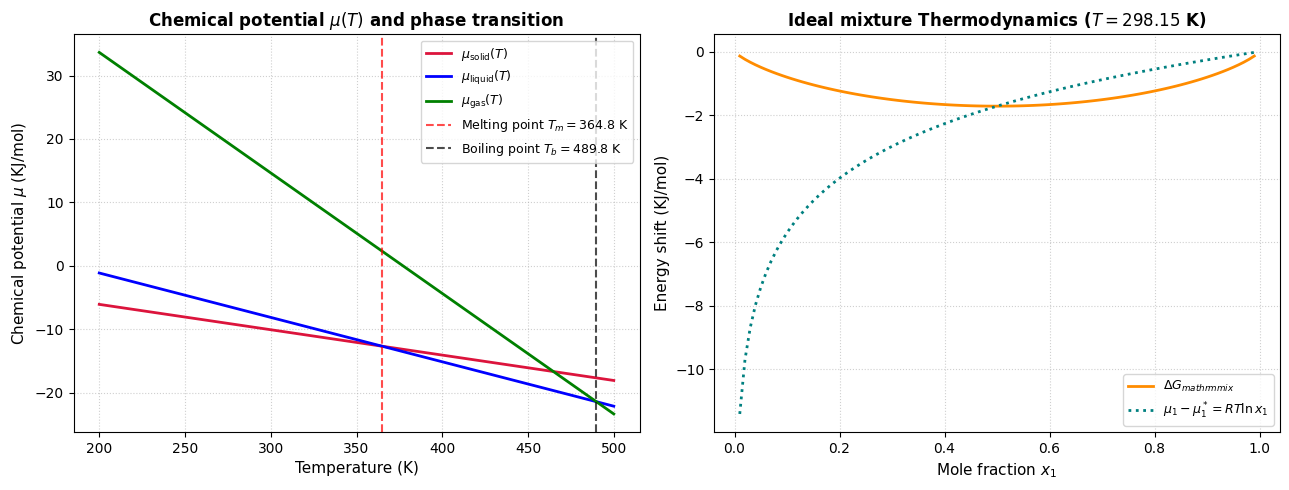

In [12]:
%matplotlib inline
import math
import matplotlib.pyplot as plt

print('='*60)
print('            Chemical Potential Simulator.            ')
print('='*60)



#Reference tempeeature T0 in K
T0 = 298.15
R = 8.314/1000 # R in KJ/mol*K

#Chemical potential at TO in KJ/mol and molar entropy S_bar in J/mol*K
#Entropy of Solid lowest, Entropy of Gas highest
mu0_solid = -10.0
S_solid = 0.040  #40 J/mol*K

mu0_liquid = -8.0
S_liquid = 0.070  #70 J/mol*K
 
mu0_gas = 15.0
S_gas = 0.190  #190 J/mol*K

#stage 1: cal mu(T) for solid, liquid, gas phase
#formula: mu_phase(T) = mu0_phase - S_phase * (T - T0)
#slope = (d_mu/dT)_P = -S_bar
temperatures = list(range(200, 505, 5))
mu_solid_list = []
mu_liquid_list = []
mu_gas_list = []
 
for T in temperatures:
	mu_s = mu0_solid - S_solid * (T - T0)
	mu_l = mu0_liquid - S_liquid * (T - T0)
	mu_g = mu0_gas - S_gas * (T - T0)
	
	mu_solid_list.append(mu_s)
	mu_liquid_list.append(mu_l)
	mu_gas_list.append(mu_g)

#stage 2: Calculate  phase change temperatures (meltingT_m and boling T_b)
#T_m = mu_solid = mu_liquid 
#T_b = mu_liquid = mu_gas 
Tm = T0 + (mu0_liquid - mu0_solid) / (S_liquid - S_solid)
Tb = T0 + (mu0_gas - mu0_liquid) / (S_gas - S_liquid)

print(f'Calculated melting point (T_m): {Tm: .2f} K')
print(f'Calculated boiling point (T_b): {Tb: .2f} K')

#stage 3: calculate delta G mixing and chemical potential shift

x1_range = [i/100.0 for i in range(1, 100)]
T_mix = 298.15

dG_mix_list = []
dmu1_list = []

for x1 in x1_range:
    x2 = 1.0 - x1
    dG_m = R * T_mix * (x1 * math.log(x1) + x2 * math.log(x2))
    dmu1 = R * T_mix * math.log(x1)
    dG_mix_list.append(dG_m)
    dmu1_list.append(dmu1)
    print(f'\nAt T = {T_mix} K, mole fraction x1 = {x1: .2f}')
    print(f'Delta G mix = {dG_m:.3f} KJ/mol')
    print(f'chemical potential shift (mu1 - mu1*): {dmu1: .3f} KJ/mol')
            
#stage 4: plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
#subplot 1: chemical potential vs temperatures across phases
ax1.plot(
       temperatures,
       mu_solid_list,
       color='crimson',
       linewidth=2,
       label=r'$\mu_{\mathrm{solid}}(T)$',
)
ax1.plot(
      temperatures,
      mu_liquid_list,
      color='blue',
      linewidth=2,
      label=r'$\mu_{\mathrm{liquid}}(T)$',
)
ax1.plot(
      temperatures,
      mu_gas_list,
      color='green',
      linewidth=2,
      label=r'$\mu_{\mathrm{gas}}(T)$',
)
#highlight transition points
ax1.axvline(
       Tm,
       color='red',
       linestyle='--',
       alpha=0.7,
       label=f'Melting point $T_m = {Tm: .1f}$ K',
)
ax1.axvline(
      Tb,
      color='black',
      linestyle='--',
      alpha=0.7,
      label=f'Boiling point $T_b = {Tb: .1f}$ K',
)
ax1.set_title(
       r'Chemical potential $\mu(T)$ and phase transition', fontsize=12, fontweight='bold'
       )
ax1.set_xlabel('Temperature (K)', fontsize=11)
ax1.set_ylabel(r'Chemical potential $\mu$ (KJ/mol)', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=9)

#subplot 2: free energy mixing vs chemical potential shift
ax2.plot(
        x1_range,
        dG_mix_list,
        color='darkorange',
        linewidth=2,
        label=r'$\Delta G_{mathrm{mix}}$',
)
ax2.plot(
        x1_range,
        dmu1_list,
        color='teal',
        linestyle=':',
        linewidth=2,
        label=r'$\mu_1 - \mu_1^* = RT \ln x_1$'
)
ax2.set_title(
           r'Ideal mixture Thermodynamics ($T = 298.15$ K)', fontsize=12, fontweight='bold'
 )
ax2.set_xlabel('Mole fraction $x_1$', fontsize=11)
ax2.set_ylabel('Energy shift (KJ/mol)', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

